In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
from sklearn.metrics import r2_score
from matplotlib.lines import Line2D

sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/')
from funcs import *
from processing_funcs import *
from theoretical import *
from analysis_funcs import *

import matplotlib.style as mplstyle
mplstyle.use(["ggplot", "fast"])

import warnings
warnings.filterwarnings("ignore")

sys.path.append('/Users/kjesta/Desktop/LABDATA/Kjersti_260126/')

#figpath = '/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/No plates/20cm/Figures/'

%load_ext autoreload
%autoreload 2

Reading in the pre-processed files

The files are cleaned, detrended, corrected for outliers and later combined as the mean of three consecutive runs per experiment.

In [2]:
# f = 1.1 Hz
# Empty tank
f1_a1 = pd.read_csv('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/Processed_files/20cm_f11_a01_processed.csv')
f1_a2 = pd.read_csv('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/Processed_files/20cm_f11_a02_processed.csv')
f1_a3 = pd.read_csv('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/Processed_files/20cm_f11_a03_processed.csv')

# With 5 cm tall plates
f1_a1_p005 = pd.read_csv('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/Processed_files/20cm_f11_a01_p005_processed.csv')
f1_a2_p005 = pd.read_csv('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/Processed_files/20cm_f11_a02_p005_processed.csv')
f1_a3_p005 = pd.read_csv('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/Processed_files/20cm_f11_a03_p005_processed.csv')

# With 10 cm tall plates

# f = 1.2 Hz
# Empty tank
f2_a1 = pd.read_csv('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/Processed_files/20cm_f12_a01_processed.csv')
f2_a2 = pd.read_csv('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/Processed_files/20cm_f12_a02_processed.csv')
f2_a3 = pd.read_csv('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/Processed_files/20cm_f12_a03_processed.csv')

# With 5 cm tall plates
f2_a1_p005 = pd.read_csv('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/Processed_files/20cm_f12_a01_p005_processed.csv')
f2_a2_p005 = pd.read_csv('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/Processed_files/20cm_f12_a02_p005_processed.csv')
f2_a3_p005 = pd.read_csv('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/Processed_files/20cm_f12_a03_p005_processed.csv')

# With 10 cm tall plates

# f = 1.3 Hz
# Empty tank
f3_a1 = pd.read_csv('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/Processed_files/20cm_f13_a01_processed.csv')
f3_a2 = pd.read_csv('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/Processed_files/20cm_f13_a02_processed.csv')
f3_a3 = pd.read_csv('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/Processed_files/20cm_f13_a03_processed.csv')

# With 5 cm tall plates
f3_a1_p005 = pd.read_csv('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/Processed_files/20cm_f13_a01_p005_processed.csv')
f3_a2_p005 = pd.read_csv('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/Processed_files/20cm_f13_a02_p005_processed.csv')
f3_a3_p005 = pd.read_csv('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/Processed_files/20cm_f13_a03_p005_processed.csv')

# With 10 cm tall plates

In [3]:
x_probe_pos = np.array([4.86, 6.69, 7.87, 9.15])  # Base positions, meters from wave maker

plate_pos = np.array([6.34, 9.38])  # Positions of the plates, meters from wave maker

In [4]:
amp_f1_a1, err_f1_a1 = get_amp_n_err_lists(f1_a1)
amp_f1_a1_p005, err_f1_a1_p005 = get_amp_n_err_lists(f1_a1_p005)
amp_f1_a2, err_f1_a2 = get_amp_n_err_lists(f1_a2)
amp_f1_a2_p005, err_f1_a2_p005 = get_amp_n_err_lists(f1_a2_p005)
amp_f1_a3, err_f1_a3 = get_amp_n_err_lists(f1_a3)
amp_f1_a3_p005, err_f1_a3_p005 = get_amp_n_err_lists(f1_a3_p005)

amp_f2_a1, err_f2_a1 = get_amp_n_err_lists(f2_a1)
amp_f2_a1_p005, err_f2_a1_p005 = get_amp_n_err_lists(f2_a1_p005)
amp_f2_a2, err_f2_a2 = get_amp_n_err_lists(f2_a2)
amp_f2_a2_p005, err_f2_a2_p005 = get_amp_n_err_lists(f2_a2_p005)
amp_f2_a3, err_f2_a3 = get_amp_n_err_lists(f2_a3)
amp_f2_a3_p005, err_f2_a3_p005 = get_amp_n_err_lists(f2_a3_p005)

amp_f3_a1, err_f3_a1 = get_amp_n_err_lists(f3_a1)
amp_f3_a1_p005, err_f3_a1_p005 = get_amp_n_err_lists(f3_a1_p005)
amp_f3_a2, err_f3_a2 = get_amp_n_err_lists(f3_a2)
amp_f3_a2_p005, err_f3_a2_p005 = get_amp_n_err_lists(f3_a2_p005)
amp_f3_a3, err_f3_a3 = get_amp_n_err_lists(f3_a3)
amp_f3_a3_p005, err_f3_a3_p005 = get_amp_n_err_lists(f3_a3_p005)

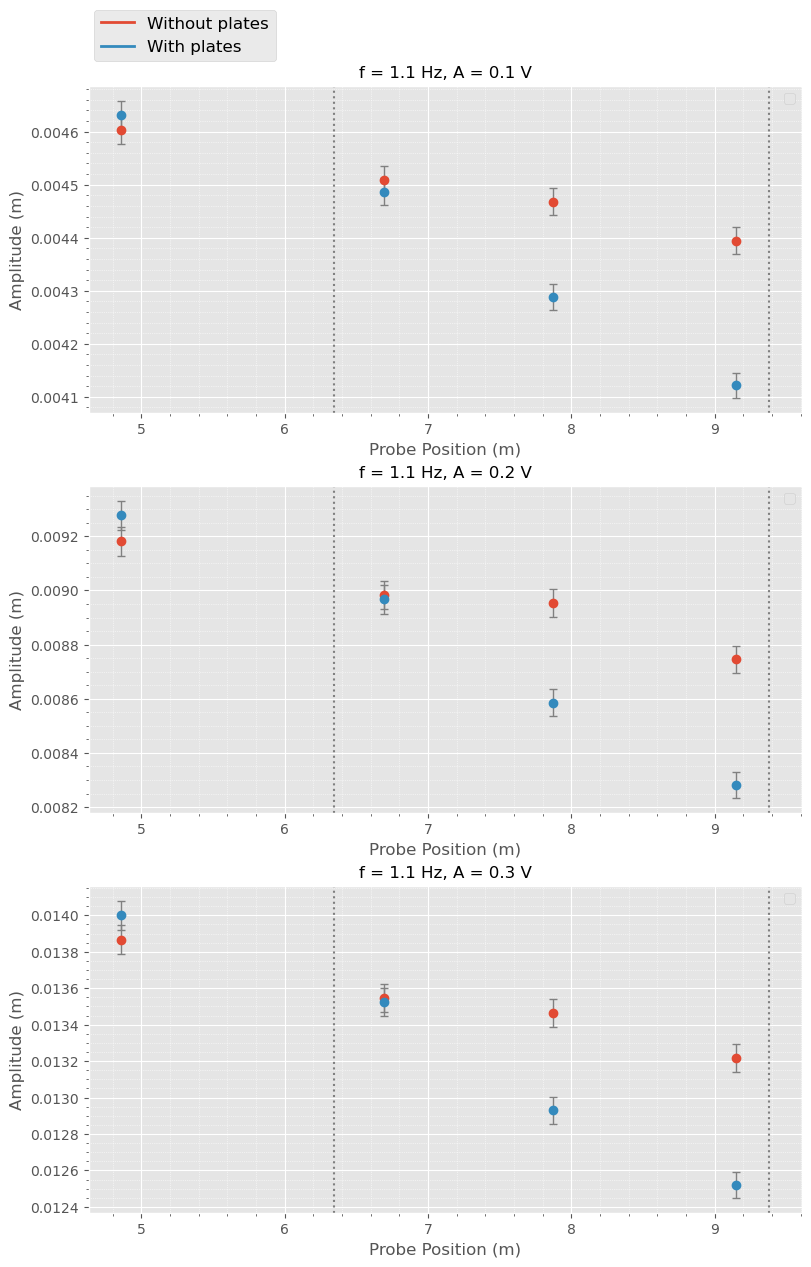

In [7]:
# Plotting
fig, ax = plt.subplots(3, 1, figsize=(8, 12), constrained_layout=True)

# A = 0.1 V
ax[0].errorbar(x_probe_pos,
            amp_f1_a1,
            yerr=err_f1_a1,
            fmt='o',
            ecolor='grey',
            elinewidth=1,
            capsize=3)

ax[0].errorbar(x_probe_pos,
            amp_f1_a1_p005,
            yerr=err_f1_a1_p005,
            fmt='o',
            ecolor='grey',
            elinewidth=1,
            capsize=3)

# A = 0.2 V
ax[1].errorbar(x_probe_pos,
            amp_f1_a2,
            yerr=err_f1_a2,
            fmt='o',
            ecolor='grey',
            elinewidth=1,
            capsize=3)

ax[1].errorbar(x_probe_pos,
               amp_f1_a2_p005,
               yerr=err_f1_a2_p005,
               fmt='o',
               ecolor='grey',
               elinewidth=1,
               capsize=3)

# A = 0.3 V
ax[2].errorbar(x_probe_pos,
            amp_f1_a3,
            yerr=err_f1_a3,
            fmt='o',
            ecolor='grey',
            elinewidth=1,
            capsize=3)

ax[2].errorbar(x_probe_pos,
               amp_f1_a3_p005,
               yerr=err_f1_a3_p005,
               fmt='o',
               ecolor='grey',
               elinewidth=1,
               capsize=3)

for axs in ax:
    axs.axvline(x=plate_pos[0], color='0.5', linestyle=':')
    axs.axvline(x=plate_pos[1], color='0.5', linestyle=':')
    axs.grid(which='minor', linestyle=':', linewidth='0.5', color='white')
    axs.minorticks_on()
    axs.set_xlabel('Probe Position (m)', fontsize=12)
    axs.set_ylabel('Amplitude (m)', fontsize=12)
    axs.legend(fontsize=10, loc='upper right')

ax[0].set_title(f'f = 1.1 Hz, A = 0.1 V', fontsize=12)
ax[1].set_title(f'f = 1.1 Hz, A = 0.2 V', fontsize=12)
ax[2].set_title(f'f = 1.1 Hz, A = 0.3 V', fontsize=12)

handles = [Line2D([0], [0], linestyle=None, color='C0', lw=2, label='Without plates'),
           Line2D([0], [0], linestyle=None, color='C1', lw=2, label='With plates')]

fig.legend(handles=handles, loc='upper left', fontsize=12, bbox_to_anchor=(0.1, 1.05))

In [13]:
k_f1 = estimate_wavenumber(freq=1.1, depth=0.2)

alpha_theo_f1 = spatial_damping_coefficient(k=k_f1, D=0.2, H=0.15)

alpha_obs_f1_a1= get_obs_alpha(amp_f1_a1, x_probe_pos)
alpha_obs_f1_a1_p005 = get_obs_alpha(amp_f1_a1_p005, x_probe_pos)
alpha_obs_f1_a2 = get_obs_alpha(amp_f1_a2, x_probe_pos)
alpha_obs_f1_a2_p005 = get_obs_alpha(amp_f1_a2_p005, x_probe_pos)
alpha_obs_f1_a3 = get_obs_alpha(amp_f1_a3, x_probe_pos)
alpha_obs_f1_a3_p005 = get_obs_alpha(amp_f1_a3_p005, x_probe_pos)

In [16]:

print('Theoretical spatial damping coefficient (f=1.1 Hz): ', f'{alpha_theo_f1:.4f}\n')
print('Observed spatial damping coefficients (f=1.1 Hz):')
print(f' A=0.1 V, no plates: {alpha_obs_f1_a1[0]:.4f}, with plates: {alpha_obs_f1_a1_p005[0]:.4f}')
print(f' A=0.2 V, no plates: {alpha_obs_f1_a2[0]:.4f}, with plates: {alpha_obs_f1_a2_p005[0]:.4f}')
print(f' A=0.3 V, no plates: {alpha_obs_f1_a3[0]:.4f}, with plates: {alpha_obs_f1_a3_p005[0]:.4f}')

Theoretical spatial damping coefficient (f=1.1 Hz):  0.0148

Observed spatial damping coefficients (f=1.1 Hz):
 A=0.1 V, no plates: 0.0105, with plates: 0.0277
 A=0.2 V, no plates: 0.0106, with plates: 0.0270
 A=0.3 V, no plates: 0.0107, with plates: 0.0267
